# Experiment 8: Convolutional Neural Network (CNN) with Keras/TensorFlow

This notebook builds and trains a CNN on image datasets with proper visualization and illustration.

Covered steps:
1. Load dataset (MNIST or CIFAR-10)
2. Preprocess images
3. Build CNN architecture
4. Train with validation
5. Evaluate performance
6. Visualize confusion matrix, predictions, and feature maps

## 1. Imports

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


## 2. Configuration

Set `DATASET_NAME` to `MNIST` or `CIFAR10`.

In [2]:
DATASET_NAME = 'MNIST'   # Options: 'MNIST', 'CIFAR10'
EPOCHS = 15
BATCH_SIZE = 128
VAL_SIZE = 0.1

print('Selected dataset:', DATASET_NAME)

Selected dataset: MNIST


## 3. Load Dataset

In [3]:
if DATASET_NAME.upper() == 'MNIST':
    (X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()
    class_names = [str(i) for i in range(10)]

    # Add channel dimension for CNN: (H, W) -> (H, W, 1)
    X_train_full = np.expand_dims(X_train_full, axis=-1)
    X_test = np.expand_dims(X_test, axis=-1)

elif DATASET_NAME.upper() == 'CIFAR10':
    (X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()
    y_train_full = y_train_full.squeeze()
    y_test = y_test.squeeze()

    class_names = [
        'airplane', 'automobile', 'bird', 'cat', 'deer',
        'dog', 'frog', 'horse', 'ship', 'truck'
    ]
else:
    raise ValueError("DATASET_NAME must be either 'MNIST' or 'CIFAR10'")

print('X_train_full shape:', X_train_full.shape)
print('y_train_full shape:', y_train_full.shape)
print('X_test shape      :', X_test.shape)
print('y_test shape      :', y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
X_train_full shape: (60000, 28, 28, 1)
y_train_full shape: (60000,)
X_test shape      : (10000, 28, 28, 1)
y_test shape      : (10000,)


## 4. Data Visualization

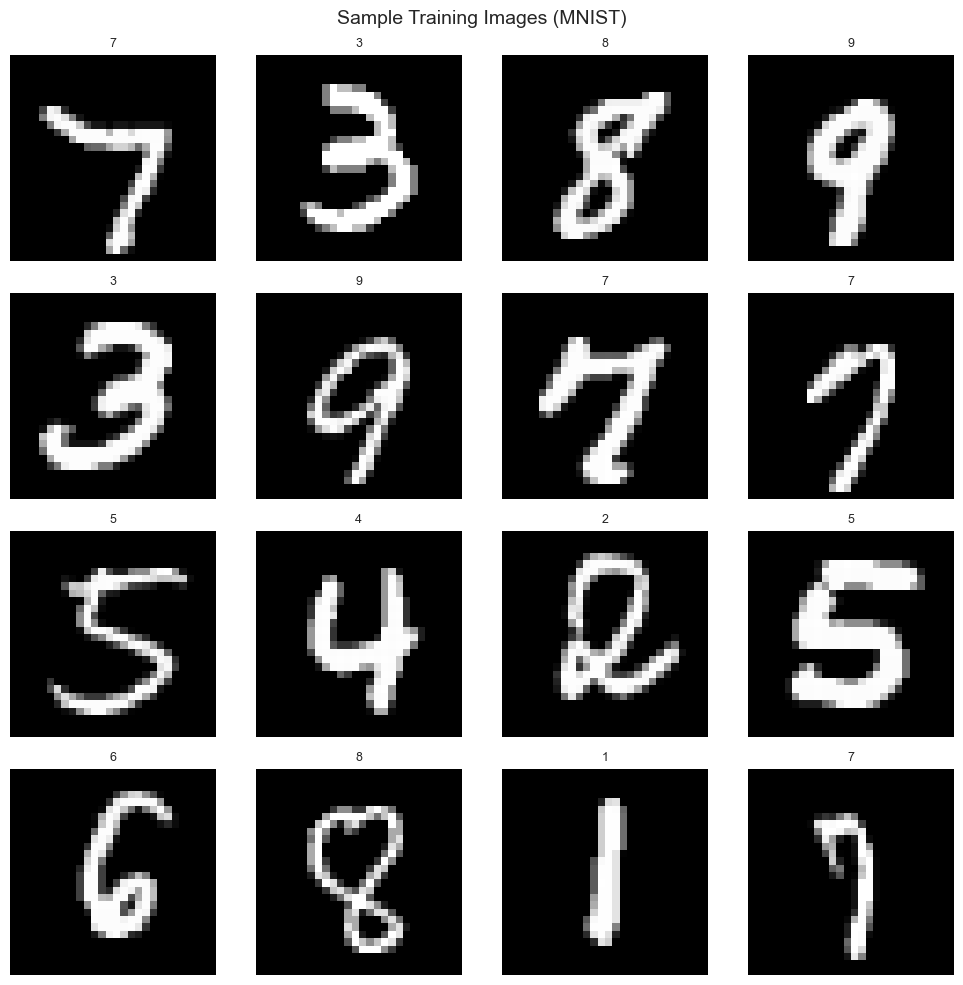

In [4]:
# Show sample images
n_show = 16
indices = np.random.choice(len(X_train_full), n_show, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
axes = axes.flatten()

for i, idx in enumerate(indices):
    img = X_train_full[idx]
    label = y_train_full[idx]

    if img.shape[-1] == 1:
        axes[i].imshow(img.squeeze(), cmap='gray')
    else:
        axes[i].imshow(img)

    axes[i].set_title(class_names[label], fontsize=9)
    axes[i].axis('off')

plt.suptitle(f'Sample Training Images ({DATASET_NAME})', fontsize=14)
plt.tight_layout()
plt.show()

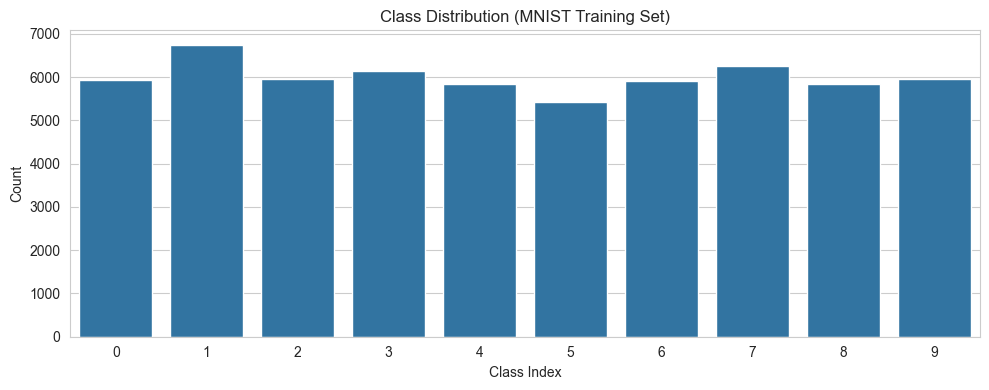

In [5]:
# Class distribution in training set
plt.figure(figsize=(10, 4))
sns.countplot(x=y_train_full)
plt.title(f'Class Distribution ({DATASET_NAME} Training Set)')
plt.xlabel('Class Index')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 5. Preprocessing

In [6]:
# Normalize pixel values to [0, 1]
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=VAL_SIZE, random_state=SEED, stratify=y_train_full
)

print('Train shape:', X_train.shape, y_train.shape)
print('Val shape  :', X_val.shape, y_val.shape)
print('Test shape :', X_test.shape, y_test.shape)

Train shape: (54000, 28, 28, 1) (54000,)
Val shape  : (6000, 28, 28, 1) (6000,)
Test shape : (10000, 28, 28, 1) (10000,)


## 6. Build CNN Model

In [7]:
def build_cnn(input_shape, num_classes, dataset_name):
    inputs = keras.Input(shape=input_shape, name='input_image')
    x = inputs

    # Light augmentation for CIFAR-10 (helps generalization).
    if dataset_name.upper() == 'CIFAR10':
        aug = keras.Sequential([
            layers.RandomFlip('horizontal'),
            layers.RandomRotation(0.05)
        ], name='augmentation')
        x = aug(x)

    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='conv1')(x)
    x = layers.MaxPooling2D((2, 2), name='pool1')(x)

    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool2')(x)

    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu', name='conv3')(x)
    x = layers.MaxPooling2D((2, 2), name='pool3')(x)

    x = layers.Flatten(name='flatten')(x)
    x = layers.Dense(128, activation='relu', name='dense1')(x)
    x = layers.Dropout(0.3, name='dropout1')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs, outputs, name=f'{dataset_name.lower()}_cnn')
    return model

model = build_cnn(input_shape=X_train.shape[1:], num_classes=len(class_names), dataset_name=DATASET_NAME)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "mnist_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Optional architecture diagram
try:
    keras.utils.plot_model(model, show_shapes=True, show_layer_names=True, dpi=80)
except Exception as e:
    print('plot_model could not render. This is optional.')
    print('Reason:', e)

You must install pydot (`pip install pydot`) for `plot_model` to work.


## 7. Train CNN

In [9]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9196 - loss: 0.2597 - val_accuracy: 0.9793 - val_loss: 0.0731 - learning_rate: 0.0010
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9794 - loss: 0.0676 - val_accuracy: 0.9867 - val_loss: 0.0525 - learning_rate: 0.0010
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9864 - loss: 0.0457 - val_accuracy: 0.9873 - val_loss: 0.0495 - learning_rate: 0.0010
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9890 - loss: 0.0365 - val_accuracy: 0.9880 - val_loss: 0.0485 - learning_rate: 0.0010
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9906 - loss: 0.0301 - val_accuracy: 0.9905 - val_loss: 0.0371 - learning_rate: 0.0010
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9918 - loss: 0.0262 - val_accuracy: 0.9913 - val_loss: 0.0373 - learning_rate: 0.0010
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9940 - loss: 0

## 8. Training Curves

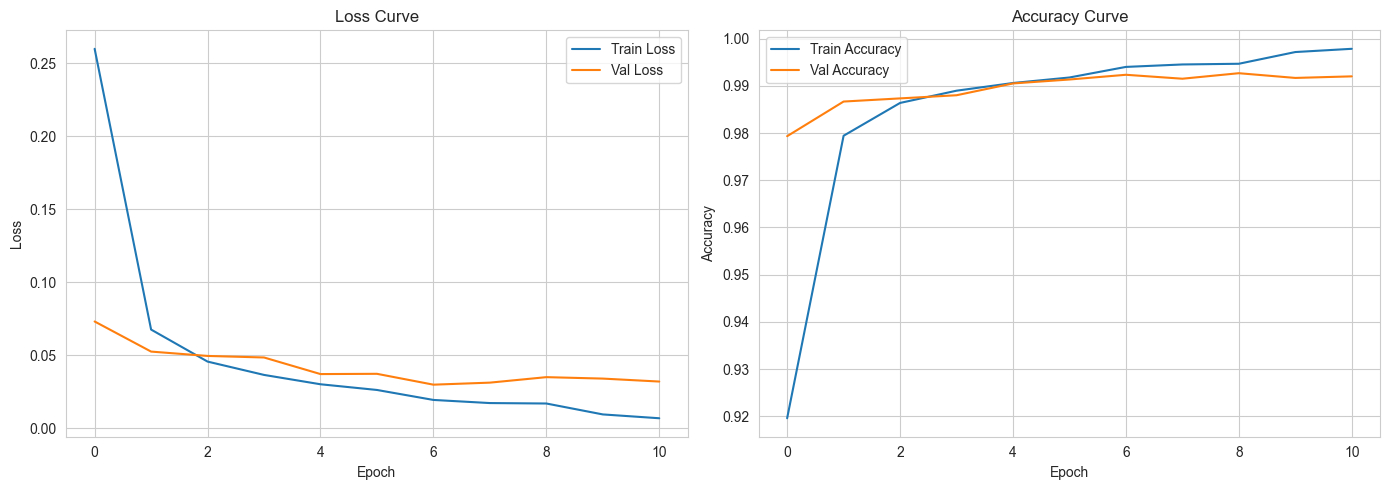

In [10]:
hist = pd.DataFrame(history.history)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(hist['loss'], label='Train Loss')
ax[0].plot(hist['val_loss'], label='Val Loss')
ax[0].set_title('Loss Curve')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[1].plot(hist['accuracy'], label='Train Accuracy')
ax[1].plot(hist['val_accuracy'], label='Val Accuracy')
ax[1].set_title('Accuracy Curve')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.tight_layout()
plt.show()

## 9. Evaluation on Test Data

In [11]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss    : {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

y_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_proba, axis=1)

Test Loss    : 0.0231
Test Accuracy: 0.9920


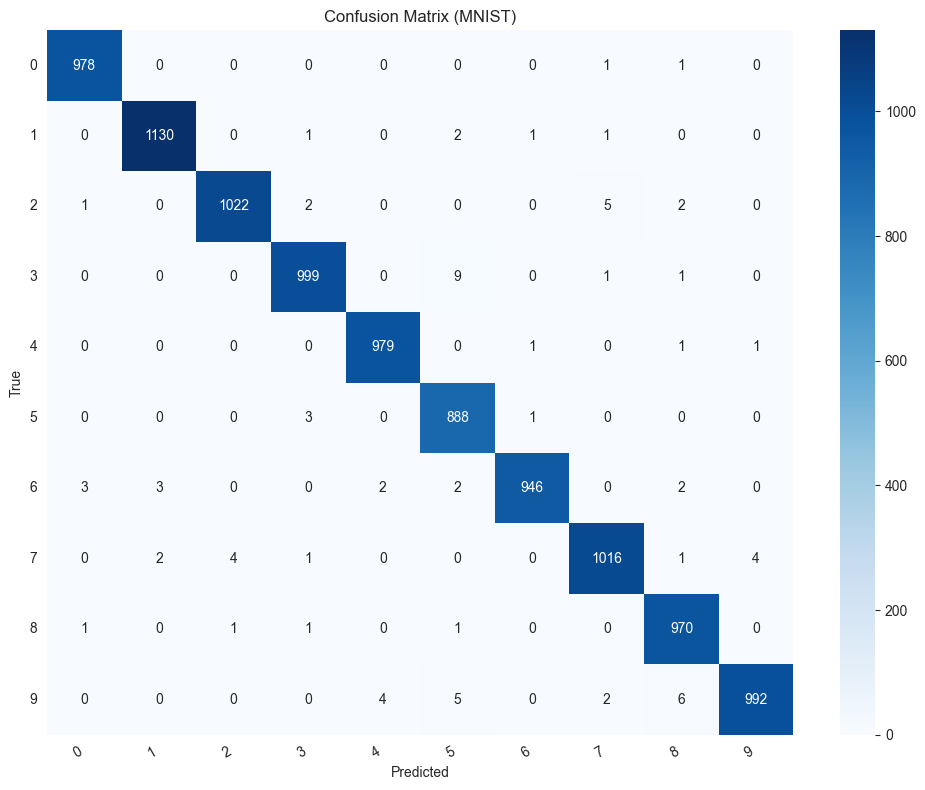

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix ({DATASET_NAME})')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       1.00      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      1.00       982
           5       0.98      1.00      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      1.00      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



## 10. Prediction Illustration

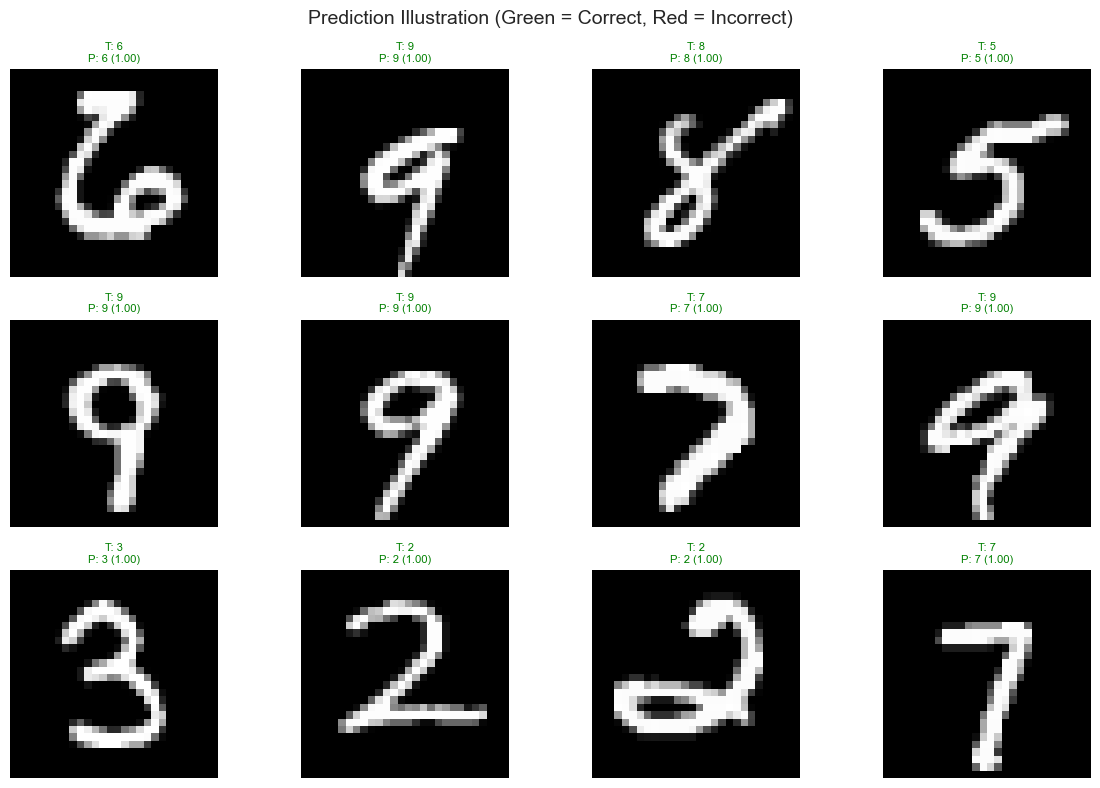

In [14]:
n_vis = 12
vis_idx = np.random.choice(len(X_test), n_vis, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(12, 8))
axes = axes.flatten()

for i, idx in enumerate(vis_idx):
    img = X_test[idx]
    true_label = y_test[idx]
    pred_label = y_pred[idx]
    confidence = np.max(y_proba[idx])

    if img.shape[-1] == 1:
        axes[i].imshow(img.squeeze(), cmap='gray')
    else:
        axes[i].imshow(img)

    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(
        f'T: {class_names[true_label]}\nP: {class_names[pred_label]} ({confidence:.2f})',
        fontsize=8, color=color
    )
    axes[i].axis('off')

plt.suptitle('Prediction Illustration (Green = Correct, Red = Incorrect)', fontsize=14)
plt.tight_layout()
plt.show()

Total misclassified test samples: 80


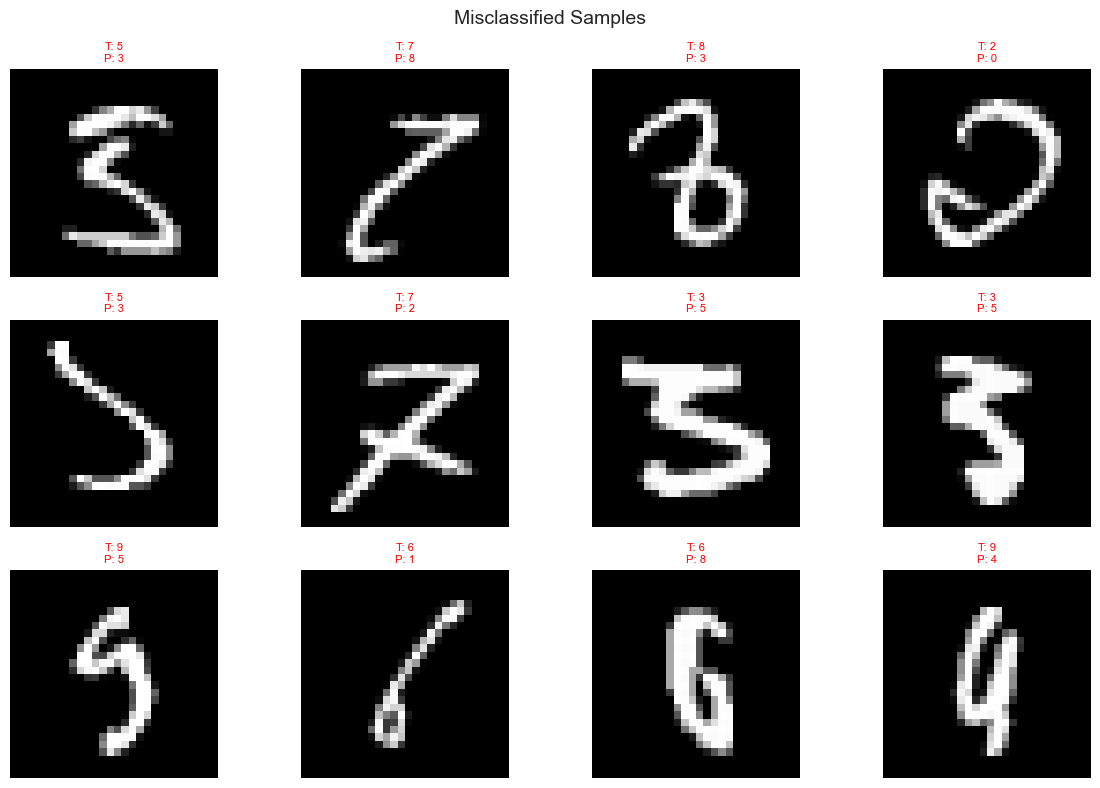

In [15]:
# Misclassified examples
mis_idx = np.where(y_pred != y_test)[0]
print('Total misclassified test samples:', len(mis_idx))

if len(mis_idx) > 0:
    show = min(12, len(mis_idx))
    chosen = np.random.choice(mis_idx, show, replace=False)

    fig, axes = plt.subplots(3, 4, figsize=(12, 8))
    axes = axes.flatten()

    for i, idx in enumerate(chosen):
        img = X_test[idx]
        if img.shape[-1] == 1:
            axes[i].imshow(img.squeeze(), cmap='gray')
        else:
            axes[i].imshow(img)

        axes[i].set_title(f'T: {class_names[y_test[idx]]}\nP: {class_names[y_pred[idx]]}', fontsize=8, color='red')
        axes[i].axis('off')

    plt.suptitle('Misclassified Samples', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('No misclassified examples found.')

## 11. Feature Map Illustration

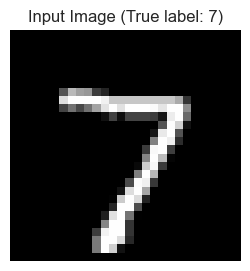

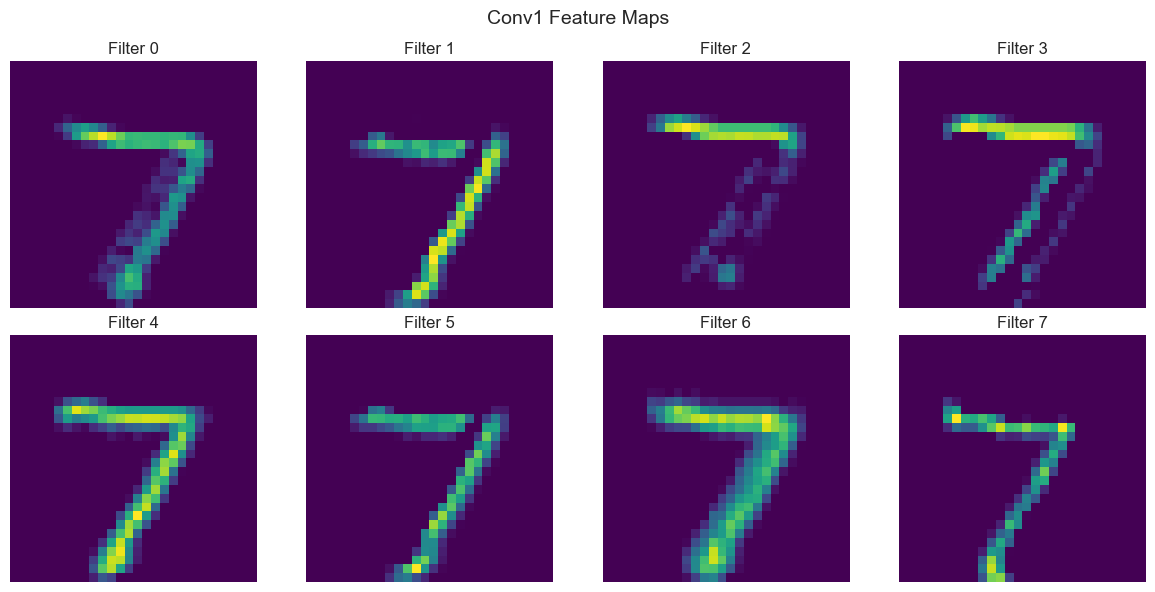

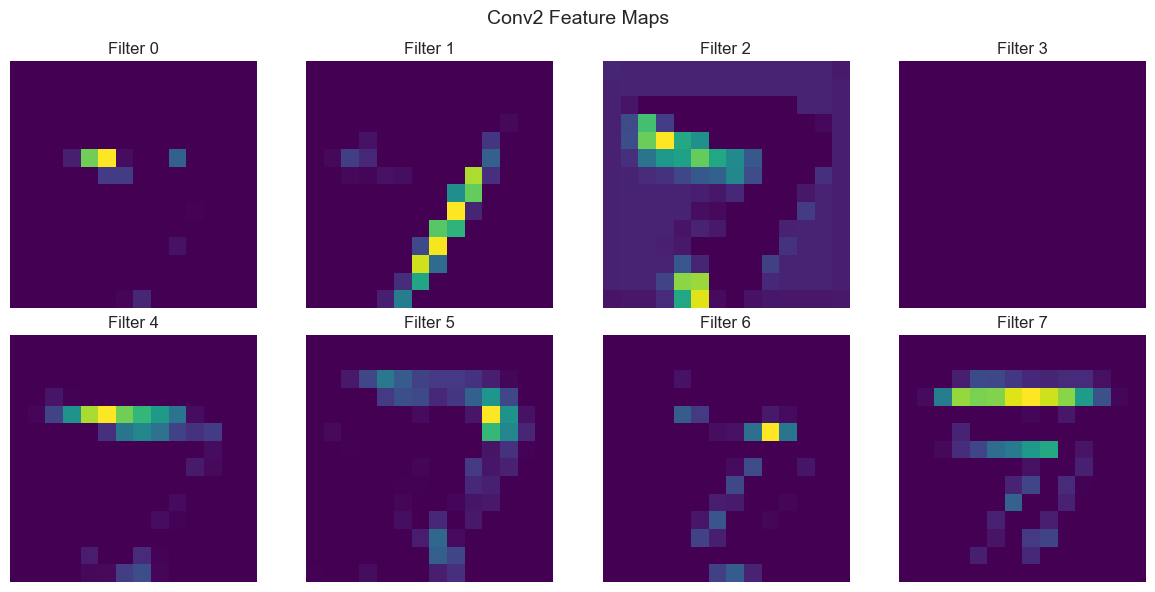

In [16]:
# Visualize activation maps from early convolution layers for one sample.
sample_id = 0
sample_img = X_test[sample_id:sample_id + 1]

activation_model = keras.Model(
    inputs=model.input,
    outputs=[model.get_layer('conv1').output, model.get_layer('conv2').output]
)

act1, act2 = activation_model.predict(sample_img, verbose=0)

def plot_feature_maps(feature_maps, title, max_maps=8):
    n_maps = min(max_maps, feature_maps.shape[-1])
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.flatten()

    for i in range(n_maps):
        axes[i].imshow(feature_maps[0, :, :, i], cmap='viridis')
        axes[i].set_title(f'Filter {i}')
        axes[i].axis('off')

    for j in range(n_maps, len(axes)):
        axes[j].axis('off')

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

if sample_img.shape[-1] == 1:
    plt.figure(figsize=(3, 3))
    plt.imshow(sample_img[0].squeeze(), cmap='gray')
else:
    plt.figure(figsize=(3, 3))
    plt.imshow(sample_img[0])

plt.title(f'Input Image (True label: {class_names[y_test[sample_id]]})')
plt.axis('off')
plt.show()

plot_feature_maps(act1, 'Conv1 Feature Maps')
plot_feature_maps(act2, 'Conv2 Feature Maps')

## 12. Conclusion

This experiment demonstrates end-to-end CNN training and analysis on image data.

To switch datasets:
- Keep `DATASET_NAME = 'MNIST'` for handwritten digits (fast training).
- Change to `DATASET_NAME = 'CIFAR10'` for color object images (more complex).

Both use the same CNN workflow and visual diagnostics.